# Project description

Implement a **logistic regressio**n model using gradient descent, Adam, or any other optimization method to optimize the parameters.

- You are **only allowed to use computational libraries** such as NumPy, Math, etc for implementing the model and training process.
- You **must not** use machine learning libraries or frameworks like scikit-learn, TensorFlow, PyTorch, etc. that provide pre-built models.
- For other tasks (e.g., data processing, visualization), you are free to use any library.

After implementing the model, use it to solve the following problem: [Titanic - Machine Learning from Disaster](https://www.kaggle.com/competitions/titanic/)


# Data downloading

In [1]:
import os
import kagglehub
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

data_url = "https://raw.githubusercontent.com/ThaiLearnCoding/NLP-Labs/refs/heads/main/Lab%206%20%2B%207%20-%20ML%20and%20Linear%20Model/data/Titanic/"

train_df = pd.read_csv(data_url + "train.csv", index_col='PassengerId')
test_df = pd.read_csv(data_url + "test.csv", index_col='PassengerId')

In [2]:
train_df

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
PassengerId,,,,,,,,,,,
1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...
887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S


In [3]:
test_df

,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
PassengerId,,,,,,,,,,
892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S
...,...,...,...,...,...,...,...,...,...,...
1305,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.0500,NaN,S
1306,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C
1307,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S


# Preprocessing

## Utilities

In [4]:
from sklearn.preprocessing import OneHotEncoder

def one_hot_encoding(train_df, test_df, lst):
  for column in lst:
    encoder = OneHotEncoder(
        sparse_output = True,
        handle_unknown='infrequent_if_exist'
    )

    # Transform train dataframe
    encoded_train_data = encoder.fit_transform(train_df[[column]]).toarray()
    encoded_train_df = pd.DataFrame(
      encoded_train_data,
      columns = encoder.get_feature_names_out([column]),
      index = train_df.index
    )
    train_df = pd.concat([train_df.drop(column, axis=1), encoded_train_df], axis=1)

    # Transform test dataframe
    encoded_test_data = encoder.transform(test_df[[column]]).toarray()
    encoded_test_df = pd.DataFrame(
      encoded_test_data,
      columns = encoder.get_feature_names_out([column]),
      index = test_df.index
    )
    test_df = pd.concat([test_df.drop(column, axis=1), encoded_test_df], axis=1)
  return train_df, test_df

In [5]:
def show_distribution_on_category(df, category, prediction_column = 'Survived'):
  train_df.groupby(category)[prediction_column].mean().plot(
    kind = 'bar',
    figsize = (8,6),
    title = f'{prediction_column} by {category}'
  )
  plt.xlabel(category)
  plt.ylabel(prediction_column)
  plt.xticks(rotation = 0)
  plt.show()

In [6]:
def show_distribution_on_numerical(df, input_column, prediction_column = 'Survived'):
  counts = df.groupby([input_column, prediction_column]).size().unstack(fill_value = 0)

  counts.plot(kind = 'line', marker = 'o')
  plt.xlabel(input_column)
  plt.ylabel(prediction_column)
  plt.title('Occurrences by Category')
  plt.legend(title='Category')
  plt.show()

In [7]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler

def handle_outlier_IQR(series, alpha = 1.5):
  Q1 = series.quantile(0.25)
  Q3 = series.quantile(0.75)
  IQR = Q3 - Q1

  lower_bound = Q1 - alpha * IQR
  upper_bound = Q3 + alpha * IQR

  # Replace outlier with lower and upper bound
  series = np.clip(series, lower_bound, upper_bound)

  return series

def choose_scaler(train, test, scaler_type, Q1_range = 25.0, Q3_range = 75.0):
    if scaler_type == 'minmax':
      scaler = MinMaxScaler()
      train = handle_outlier_IQR(train)
      test = handle_outlier_IQR(test)
    elif scaler_type == 'std':
      scaler = StandardScaler()
      train = handle_outlier_IQR(train)
      test = handle_outlier_IQR(test)
    else:
      Q1 = train.quantile(Q1_range / 100.0)
      Q3 = train.quantile(Q3_range / 100.0)
      IQR = Q3 - Q1

      if IQR < 10 and train.max() > 0:
          # To handle the excessive amount of a certain values in IQR range
          return MinMaxScaler()
      else:
          scaler = RobustScaler(quantile_range=(Q1_range, Q3_range)) # Default RobustScaler

    return scaler

In [8]:
def preprocess(train_df, test_df, column, scaler_type):
  scaler = choose_scaler(train_df[column], test_df[column], scaler_type) # It support handling outlier implicitly
  train_df[column] = scaler.fit_transform(train_df[[column]])
  test_df[column] = scaler.transform(test_df[[column]])

  return train_df, test_df

## Passenger name

Passenger name can be used to fill other attribute's nan value. And the way people call them can show the respect, or hidden features. So, i will extract it here, making it ready to use at later stages

In [9]:
train_df['Title'] = train_df['Name'].str.extract(' ([A-Za-z]+)\.', expand = False) # Use expand to return a series
test_df['Title'] = test_df['Name'].str.extract(' ([A-Za-z]+)\.', expand = False)
train_df['Title'].value_counts()

<>:1: SyntaxWarning: invalid escape sequence '\.'
<>:2: SyntaxWarning: invalid escape sequence '\.'
<>:1: SyntaxWarning: invalid escape sequence '\.'
<>:2: SyntaxWarning: invalid escape sequence '\.'
/tmp/ipykernel_1554/2908027716.py:1: SyntaxWarning: invalid escape sequence '\.'
  train_df['Title'] = train_df['Name'].str.extract(' ([A-Za-z]+)\.', expand = False) # Use expand to return a series
/tmp/ipykernel_1554/2908027716.py:2: SyntaxWarning: invalid escape sequence '\.'
  test_df['Title'] = test_df['Name'].str.extract(' ([A-Za-z]+)\.', expand = False)


,count
Title,
Mr,517
Miss,182
Mrs,125
Master,40
Dr,7
Rev,6
Col,2
Mlle,2
Major,2


In [10]:
# Here, i replace those title into 3 groups, to reduce the variance
title_map = {
    "Mlle": "Miss", "Ms": "Miss", "Mme": "Mrs",
    "Lady": "Royalty", "Countess": "Royalty", "Don": "Royalty", "Sir": "Royalty", "Jonkheer": "Royalty", "Dona": "Royalty",
    "Capt": "Officer", "Col": "Officer", "Major": "Officer", "Rev": "Officer", "Dr": "Officer"
}

# Replace
train_df['Title'] = train_df['Title'].replace(title_map)
test_df['Title'] = test_df['Title'].replace(title_map)

In [11]:
train_df['Title'].value_counts()

,count
Title,
Mr,517
Miss,185
Mrs,126
Master,40
Officer,18
Royalty,5


In [12]:
train_df = train_df.drop(columns = ['Name'])
test_df = test_df.drop(columns = ['Name'])

## Embarked

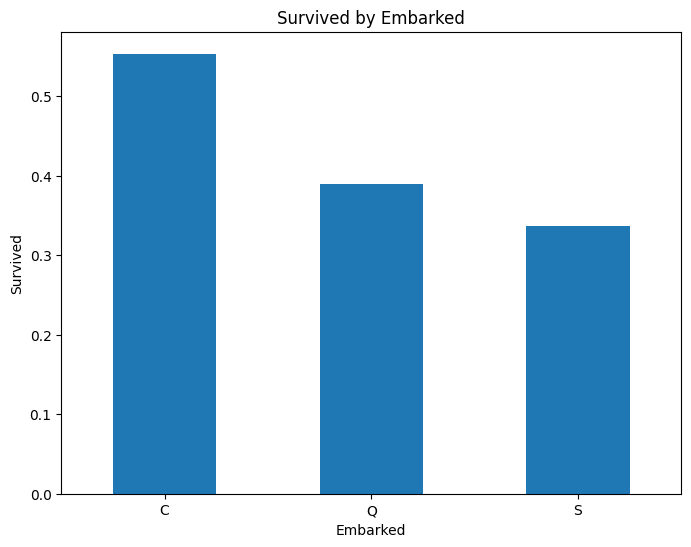

In [13]:
show_distribution_on_category(train_df, 'Embarked')

In [14]:
train_df['Embarked'].value_counts()

,count
Embarked,
S,644
C,168
Q,77


As we can see the chance of survival, and number of passenger is different according to each port embarkation. May be, it has hidden information inside it, such as there can be correlation between Embarked value, with other attributes, such as Fare, Cabin, and pclass. The correlation is complex, but the main focus on this project is to implement model and run it well. I will take it as future work here.

In conclusion, i will fill nan value with most frequent value, and encode them using one-hot encoding.

In [15]:
mod_embarked = train_df['Embarked'].mode()[0]

train_df['Embarked'] = train_df['Embarked'].fillna(mod_embarked)
test_df['Embarked'] = test_df['Embarked'].fillna(mod_embarked)

In [16]:
train_df, test_df = one_hot_encoding(train_df, test_df, ['Embarked'])

## Gender

The dataset consists only 2 genders, so i will transform it into categorical data using one-hot encoding - 0 for male, and 1 for female

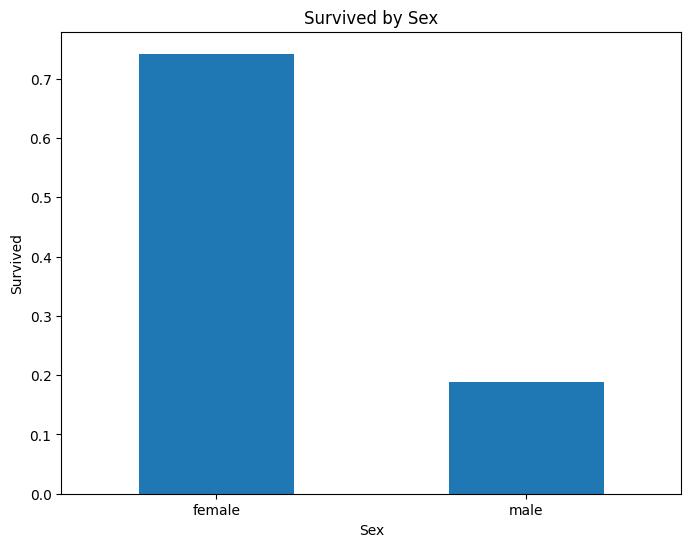

In [17]:
show_distribution_on_category(train_df, 'Sex')

In [18]:
train_df['Sex'].value_counts()

,count
Sex,
male,577
female,314


It is undoubted to say that woman have better chance to survive in those situtation than man.

In [19]:
train_df['Sex'] =  train_df['Sex'].apply(lambda x: 1 if (x == 'female') else 0)
test_df['Sex'] =  test_df['Sex'].apply(lambda x: 1 if (x == 'female') else 0)

## Age

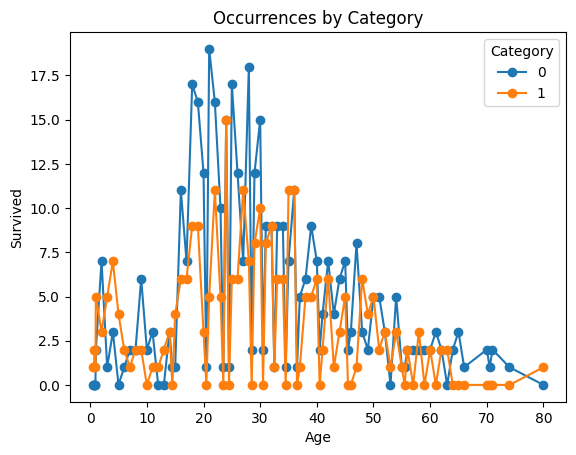

In [20]:
show_distribution_on_numerical(train_df, 'Age')

In [21]:
print("Nan value ration in the dataset: ", train_df['Age'].isna().sum() / len(train_df))

Nan value ration in the dataset:  0.19865319865319866


In [22]:
train_df['Title'].loc[train_df['Age'].isna()].value_counts()

,count
Title,
Mr,119
Miss,36
Mrs,17
Master,4
Officer,1


In [23]:
# Filling nan values
train_med = train_df.groupby('Title')['Age'].median()

train_df['Age'] = train_df['Age'].fillna(train_df['Title'].map(train_med))

test_df['Age'] = test_df['Age'].fillna(test_df['Title'].map(train_med))
test_df['Age'] = test_df['Age'].fillna(train_df['Age'].median()) # For safety :v, if there are some unexpected value

In [24]:
train_med

,Age
Title,
Master,3.5
Miss,21.0
Mr,30.0
Mrs,35.0
Officer,50.0
Royalty,40.0


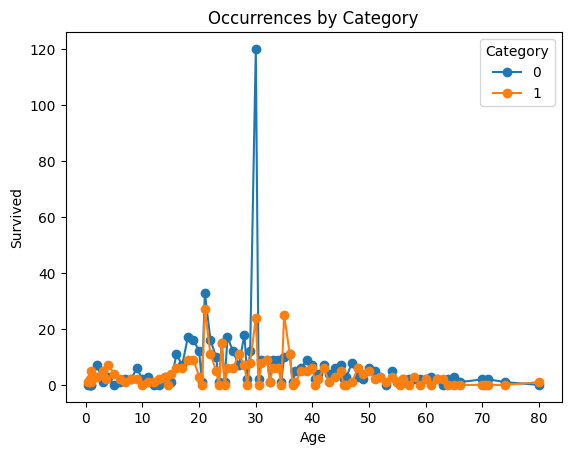

In [25]:
show_distribution_on_numerical(train_df, 'Age')

However, i will transform this continuous data into categorical value using discretization. I will split them into different range 0-12, 12-18, 18-30, 30-50, 50-80, > 80

In [26]:
age_range = [0, 12, 18, 30, 50, 80]
age_label = ['Child', 'Teen', 'Young Adult', 'Adult', 'Senior']

train_df['Age'] = pd.cut(train_df['Age'], bins = age_range, labels = age_label)
test_df['Age'] = pd.cut(test_df['Age'], bins = age_range, labels = age_label)

In [27]:
train_df, test_df = one_hot_encoding(train_df, test_df, ['Age'])

## Fare

In [28]:
train_df['Fare'].isna().sum()

np.int64(0)

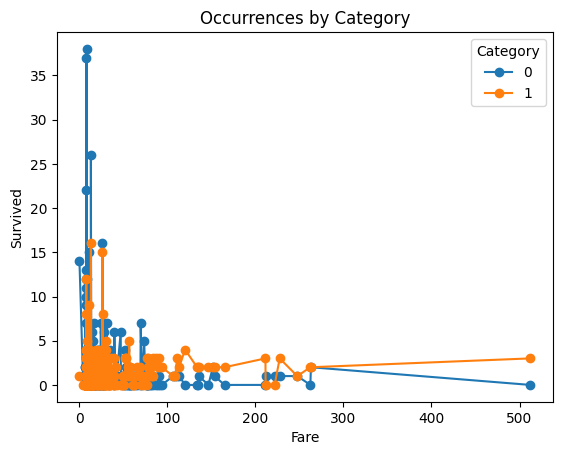

In [29]:
show_distribution_on_numerical(train_df, 'Fare')

As we can see, the value is right-skewed. So, i will use Robust Scaler to handle the outliers

In [30]:
train_df, test_df = preprocess(train_df, test_df, 'Fare', 'robust')

In [31]:
train_df

,Survived,Pclass,Sex,SibSp,Parch,Ticket,Fare,Cabin,Title,Embarked_C,Embarked_Q,Embarked_S,Age_Adult,Age_Child,Age_Senior,Age_Teen,Age_Young Adult
PassengerId,,,,,,,,,,,,,,,,,
1,0,3,0,1,0,A/5 21171,-0.312011,NaN,Mr,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
2,1,1,1,1,0,PC 17599,2.461242,C85,Mrs,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
3,1,3,1,0,0,STON/O2. 3101282,-0.282777,NaN,Miss,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
4,1,1,1,1,0,113803,1.673732,C123,Mrs,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0
5,0,3,0,0,0,373450,-0.277363,NaN,Mr,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
887,0,2,0,0,0,211536,-0.062981,NaN,Officer,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
888,1,1,1,0,0,112053,0.673281,B42,Miss,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
889,0,3,1,1,2,W./C. 6607,0.389604,NaN,Miss,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0


## SibSp

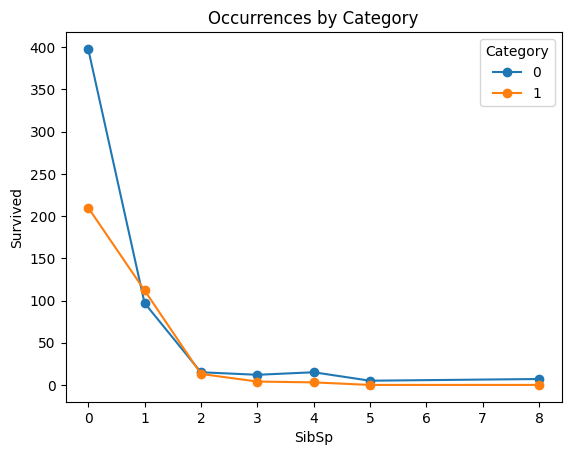

In [32]:
show_distribution_on_numerical(train_df, 'SibSp')

In [33]:
train_df['Parch'].describe()

,Parch
count,891.000000
mean,0.381594
std,0.806057
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,6.000000


Don't need to transform this attribute

## Parch

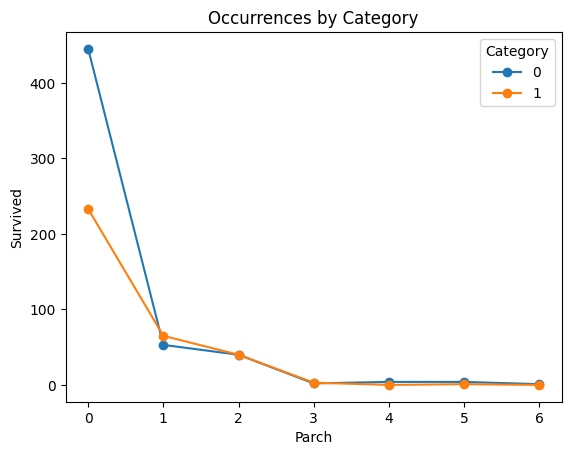

In [34]:
show_distribution_on_numerical(train_df, 'Parch')

In [35]:
train_df['Parch'].describe()

,Parch
count,891.000000
mean,0.381594
std,0.806057
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,6.000000


Don't need to transform this attribute

## Cabin

In [36]:
train_df['Cabin'] = train_df['Cabin'].str[0].fillna('U')
test_df['Cabin'] = test_df['Cabin'].str[0].fillna('U')

train_df['Cabin'] = train_df['Cabin'].replace('T', 'U')
test_df['Cabin'] = test_df['Cabin'].replace('T', 'U')

In [37]:
train_df['Cabin'].value_counts()

,count
Cabin,
U,688
C,59
B,47
D,33
E,32
A,15
F,13
G,4


In [38]:
train_df, test_df = one_hot_encoding(train_df, test_df, ['Cabin'])

## Tickt

In [39]:
# Count ticket occurrences
# As popl can go in group, they have better chance to survive
ticket_counts = train_df['Ticket'].value_counts().to_dict()
train_df['Ticket'] = train_df['Ticket'].map(ticket_counts)

test_ticket_counts = test_df['Ticket'].value_counts().to_dict()
test_df['Ticket'] = test_df['Ticket'].map(test_ticket_counts)

In [40]:
train_df['Ticket'].describe()

,Ticket
count,891.000000
mean,1.787879
std,1.361142
min,1.000000
25%,1.000000
50%,1.000000
75%,2.000000
max,7.000000


In [41]:
train_df['Ticket'].value_counts()

,count
Ticket,
1,547
2,188
3,63
4,44
7,21
6,18
5,10


In [42]:
train_df, test_df = preprocess(train_df, test_df, 'Ticket', 'std')

In [43]:
train_df['Ticket'].describe()

,Ticket
count,8.910000e+02
mean,6.180366e-17
std,1.000562e+00
min,-5.791618e-01
25%,-5.791618e-01
50%,-5.791618e-01
75%,1.559282e-01
max,3.831378e+00


## Titl

In [44]:
train_df, test_df = one_hot_encoding(train_df, test_df, ['Title'])

In [55]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 891 entries, 1 to 891
Data columns (total 29 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Survived         891 non-null    int64  
 1   Pclass           891 non-null    int64  
 2   Sex              891 non-null    int64  
 3   SibSp            891 non-null    int64  
 4   Parch            891 non-null    int64  
 5   Ticket           891 non-null    float64
 6   Fare             891 non-null    float64
 7   Embarked_C       891 non-null    float64
 8   Embarked_Q       891 non-null    float64
 9   Embarked_S       891 non-null    float64
 10  Age_Adult        891 non-null    float64
 11  Age_Child        891 non-null    float64
 12  Age_Senior       891 non-null    float64
 13  Age_Teen         891 non-null    float64
 14  Age_Young Adult  891 non-null    float64
 15  Cabin_A          891 non-null    float64
 16  Cabin_B          891 non-null    float64
 17  Cabin_C          891 

# Model training

In [45]:
class LogisticRegressionAdam:
    def __init__(self, lr=0.001, beta1=0.9, beta2=0.999, epsilon=1e-8, iterations=1000):
        self.lr = lr
        self.beta1 = beta1
        self.beta2 = beta2
        self.epsilon = epsilon
        self.iterations = iterations
        self.w = None
        self.b = None

    def _sigmoid(self, z):
        # Sigmoid activation function
        return 1 / (1 + np.exp(-z))

    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.w = np.zeros(n_features)
        self.b = 0

        # Initialize Adam moments
        m_w, v_w = np.zeros(n_features), np.zeros(n_features)
        m_b, v_b = 0, 0

        for t in range(1, self.iterations + 1):
            # Linear combination of inputs
            linear_model = np.dot(X, self.w) + self.b
            # Apply sigmoid to get probabilities
            y_pred = self._sigmoid(linear_model)

            # Gradients (for binary cross-entropy loss)
            dw = (1 / n_samples) * np.dot(X.T, (y_pred - y))
            db = (1 / n_samples) * np.sum(y_pred - y)

            # Update First Moments (Momentum)
            m_w = self.beta1 * m_w + (1 - self.beta1) * dw
            m_b = self.beta1 * m_b + (1 - self.beta1) * db

            # Update Second Moments (RMSProp)
            v_w = self.beta2 * v_w + (1 - self.beta2) * (dw**2)
            v_b = self.beta2 * v_b + (1 - self.beta2) * (db**2)

            # Bias Correction
            m_w_hat = m_w / (1 - self.beta1**t)
            m_b_hat = m_b / (1 - self.beta1**t)
            v_w_hat = v_w / (1 - self.beta2**t)
            v_b_hat = v_b / (1 - self.beta2**t)

            # Parameter Update
            self.w -= self.lr * m_w_hat / (np.sqrt(v_w_hat) + self.epsilon)
            self.b -= self.lr * m_b_hat / (np.sqrt(v_b_hat) + self.epsilon)

            # Print cost to check convergence (using binary cross-entropy)
            if t % 100 == 0:
                # Avoid log(0) by clipping probabilities
                y_pred_clipped = np.clip(y_pred, 1e-10, 1 - 1e-10)
                cost = -(1 / n_samples) * np.sum(y * np.log(y_pred_clipped) + (1 - y) * np.log(1 - y_pred_clipped))
                print(f"Iteration {t}: Cost {cost:.4f}")

    def predict_proba(self, X):
        # Returns probabilities (between 0 and 1)
        linear_model = np.dot(X, self.w) + self.b
        return self._sigmoid(linear_model)

    def predict(self, X):
        # Returns binary predictions (0 or 1)
        return (self.predict_proba(X) >= 0.5).astype(int)

In [46]:
from sklearn.model_selection import train_test_split

X = train_df.drop('Survived', axis=1)
y = train_df['Survived']

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.25, random_state=42)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_val: {X_val.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_val: {y_val.shape}")

Shape of X_train: (668, 28)
Shape of X_val: (223, 28)
Shape of y_train: (668,)
Shape of y_val: (223,)


In [47]:
from sklearn.metrics import accuracy_score

def train_model(model, X_train, y_train, X_val, y_val):
    print(f"Training {model.__class__.__name__}...")
    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)
    y_val_pred = model.predict(X_val)

    accuracy_train = accuracy_score(y_train, y_train_pred)
    accuracy_val = accuracy_score(y_val, y_val_pred)

    print(f"Accuracy on training set: {accuracy_train:.4f}")
    print(f"Accuracy on validation set: {accuracy_val:.4f}")

    return model, y_train_pred, y_val_pred

In [48]:
logistic_adam_model = LogisticRegressionAdam(
    lr = 0.01,
    beta1=0.9,
    beta2=0.99,
    epsilon=1e-7,
    iterations=2000
)

logistic_adam_model, y_train_pred_adam, y_val_pred_adam = train_model(
    logistic_adam_model, X_train, y_train, X_val, y_val
)

Training LogisticRegressionAdam...
Iteration 100: Cost 0.4242
Iteration 200: Cost 0.4031
Iteration 300: Cost 0.3998
Iteration 400: Cost 0.3994
Iteration 500: Cost 0.3994
Iteration 600: Cost 0.3994
Iteration 700: Cost 0.3993
Iteration 800: Cost 0.3993
Iteration 900: Cost 0.3993
Iteration 1000: Cost 0.3993
Iteration 1100: Cost 0.3993
Iteration 1200: Cost 0.3993
Iteration 1300: Cost 0.3993
Iteration 1400: Cost 0.3993
Iteration 1500: Cost 0.3993
Iteration 1600: Cost 0.3993
Iteration 1700: Cost 0.3993
Iteration 1800: Cost 0.3993
Iteration 1900: Cost 0.3993
Iteration 2000: Cost 0.3993
Accuracy on training set: 0.8383
Accuracy on validation set: 0.8117


# Generating CSV file

In [49]:
def generate_submission_csv(model, X_test, test_ids, filename='submission.csv'):
    predictions = model.predict(X_test)

    submission_df = pd.DataFrame({'PassengerId': test_ids, 'Survived': predictions})
    submission_df.to_csv(filename, index=False)
    return submission_df

In [50]:
X_test = test_df.copy()

# Generate
test_ids = test_df.index
submission_df = generate_submission_csv(logistic_adam_model, X_test, test_ids, 'adam_submission.csv')

display(submission_df.head())

,PassengerId,Survived
0,892,0
1,893,1
2,894,0
3,895,0
4,896,1


# Kaggle Submission Evidence

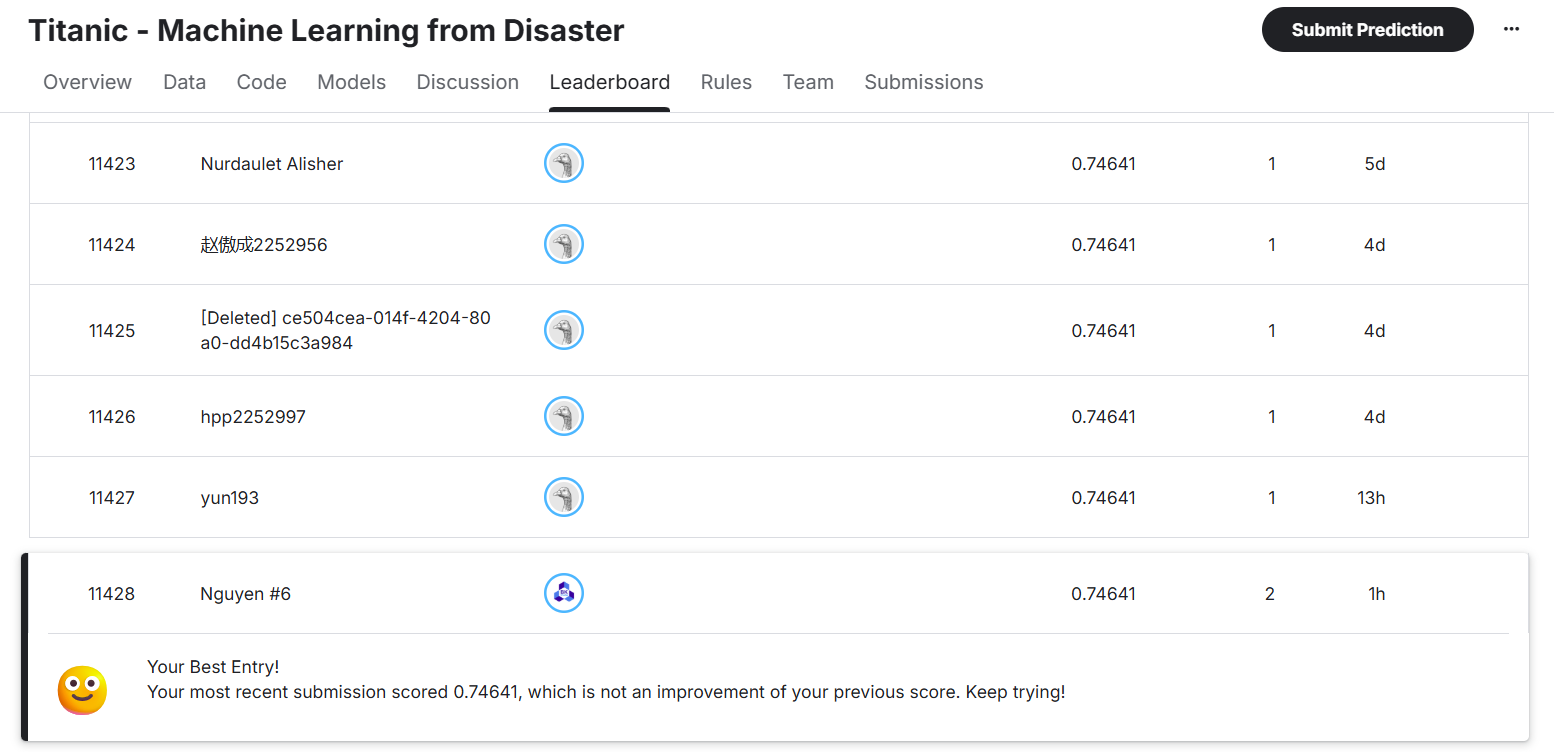